In [157]:
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from currency_converter import CurrencyConverter
import cpi
from datetime import date

In [158]:
# load in relevant files
df = pd.read_csv('data/final_dataset.csv')
keyw = pd.read_csv('data/keywords.csv')
mm = pd.read_csv("data/movies_metadata.csv")

C:\Users\ishan\AppData\Local\Temp\ipykernel_43528\1206468364.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  mm = pd.read_csv("data/movies_metadata.csv")


In [159]:
# this has the movies metadata
#https://www.kaggle.com/datasets/raedaddala/top-500-600-movies-of-each-year-from-1960-to-2024
# it is an aggregated version of this dataset
#https://www.kaggle.com/datasets/raedaddala/imdb-movies-from-1960-to-2023

# this has the keywords
#https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data

In [160]:
mm_id_key = mm[['id', 'imdb_id']]

In [161]:
def list_dict(x):
    empt = []
    for di in x:
        empt.append(di['name'])
    return empt

In [162]:
# convert the keywords from string dictionaries to lists of just keywords
keyw['keywords'] = keyw['keywords'].apply(lambda x: eval(x))
keyw['keywords'] = keyw['keywords'].apply(lambda x: list_dict(x))

In [163]:
# drop the couple of movies with no IMDB id in the dataset
mm_id_key = mm_id_key[mm_id_key['imdb_id'] != '0']
mm_id_key['id'] = pd.to_numeric(mm_id_key['id'], downcast='integer')

# merge the keywords with the primary movies dataset
key_id = keyw.merge(mm_id_key, on='id', how='inner')
key_id = key_id[['imdb_id', 'keywords']]

In [164]:
full_movies = df.merge(key_id, left_on='id', right_on='imdb_id', how='left')
full_movies = full_movies.drop('imdb_id', axis=1)

In [165]:
full_movies

,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,...,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages,keywords
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,An extortion ring murders anyone who refuses t...,https://www.imdb.com/title/tt0027483/,"['Reginald Denham', 'Edgar Wallace', 'Howard I...",...,NaN,NaN,1936-08-10,['United Kingdom'],NaN,['Richard Wainwright Productions'],NaN,['Drama'],['English'],NaN
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,"Three year old Ada, daughter of the British ca...",https://www.imdb.com/title/tt0058131/,"['Emilio Salgari', 'Arpad DeRiso', 'Ottavio Po...",...,NaN,NaN,1966-05-28,"['Italy', 'Monaco', 'West Germany']",NaN,"['Eichberg-Film', 'Liber Film']",NaN,['Adventure'],['Italian'],NaN
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,Infante stars as a rebel general caught up in ...,https://www.imdb.com/title/tt0042760/,"['Joselito Rodríguez', 'Celestino Gorostiza', ...",...,NaN,NaN,1951-07-13,['Mexico'],NaN,['Producciones Rodríguez Hermanos'],NaN,"['Drama', 'War']",['Spanish'],NaN
3,tt0027667,Gentle Julia,1h 2m,Approved,6.8,38,NaN,A shy newspaperman (Brown) nearly gives up whe...,https://www.imdb.com/title/tt0027667/,"['Booth Tarkington', 'Lamar Trotti']",...,NaN,NaN,1936-04-10,['United States'],"['20th Century Fox Studios - 10201 Pico Blvd.,...",['Twentieth Century Fox'],NaN,"['Comedy', 'Drama', 'Romance']",['English'],NaN
4,tt0055747,Love at Twenty,1h 50m,NaN,7.2,2.5K,NaN,"""Love at Twenty"" unites five directors from ar...",https://www.imdb.com/title/tt0055747/,"['Shintarô Ishihara', 'Marcel Ophüls', 'Renzo ...",...,NaN,NaN,1963-02-06,"['France', 'Italy', 'Japan', 'Poland', 'West G...","['Warsaw Zoo, Ratuszowa, Praga Pólnoc, Warsaw,...","['Ulysse Productions', 'Unitec Films', 'Cinese...",NaN,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63658,tt0160310,Girl with an Itch,1h 17m,Approved,6.4,63,NaN,"A lonely, widowed middle-aged ranch owner give...",https://www.imdb.com/title/tt0160310/,"['Ralph S. Whiting', 'Peter Perry Jr.', 'E. Sh...",...,NaN,NaN,1958-11-12,['United States'],"['Los Angeles County, California, USA']",['The Don-Tru Company'],NaN,['Drama'],['English'],NaN
63659,tt0103069,Texasville,2h 6m,R,6.0,3.2K,49.0,The summer of 1984: 32 years after Duane Jacks...,https://www.imdb.com/title/tt0103069/,"['Larry McMurtry', 'Peter Bogdanovich']",...,"$2,268,181","$2,268,181",1990-09-28,['United States'],"['Archer City, Texas, USA']","['Cine-Source', 'Nelson Entertainment']",NaN,"['Drama', 'Romance']",['English'],"[texas, high school sweetheart]"
63660,tt1473380,Kalai Arasi,2h 3m,NaN,8.0,56,NaN,Vani is kidnapped by aliens who need her to te...,https://www.imdb.com/title/tt1473380/,['T.E. Gnanamurthy'],...,NaN,NaN,1963-04-19,['India'],NaN,['Sarodi Brothers'],NaN,"['Comedy', 'Fantasy']",['Tamil'],NaN
63661,tt0247184,Aprili,45m,NaN,7.2,522,NaN,A young happy couple moves from a poor distric...,https://www.imdb.com/title/tt0247184/,"['Erlom Akhvlediani', 'Otar Iosseliani']",...,NaN,NaN,1962-09-28,['Soviet Union'],NaN,"['Georgian-Film', 'Gruziya Film', 'Qartuli Pil...",NaN,"['Comedy', 'Drama', 'Romance']",['Georgian'],[]


In [166]:
# drop the columns without relevant predictors or multicollinear predictors
full_movies = full_movies.drop(['méta_score','description', 'movie_link', 'writers', 'directors', 'stars', 'budget',
       'opening_weekend_gross','countries_origin', 'filming_locations',
       'production_companies', 'awards_content'], axis=1)

In [167]:
full_movies.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,languages,keywords
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,NaN,1936-08-10,['Drama'],['English'],NaN
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,NaN,1966-05-28,['Adventure'],['Italian'],NaN
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,NaN,1951-07-13,"['Drama', 'War']",['Spanish'],NaN
3,tt0027667,Gentle Julia,1h 2m,Approved,6.8,38,NaN,NaN,1936-04-10,"['Comedy', 'Drama', 'Romance']",['English'],NaN
4,tt0055747,Love at Twenty,1h 50m,NaN,7.2,2.5K,NaN,NaN,1963-02-06,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN


In [168]:
full_movies['eng_lang'] = full_movies['languages'].apply(lambda x: 1 if "English" in str(x) else 0)

In [169]:
full_movies.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,languages,keywords,eng_lang
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,NaN,1936-08-10,['Drama'],['English'],NaN,1
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,NaN,1966-05-28,['Adventure'],['Italian'],NaN,0
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,NaN,1951-07-13,"['Drama', 'War']",['Spanish'],NaN,0
3,tt0027667,Gentle Julia,1h 2m,Approved,6.8,38,NaN,NaN,1936-04-10,"['Comedy', 'Drama', 'Romance']",['English'],NaN,1
4,tt0055747,Love at Twenty,1h 50m,NaN,7.2,2.5K,NaN,NaN,1963-02-06,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN,0


In [170]:
full_movies.describe()

,rating,eng_lang
count,59595.000000,63663.000000
mean,6.163205,0.675997
std,1.070316,0.468005
min,1.000000,0.000000
25%,5.500000,0.000000
50%,6.300000,1.000000
75%,6.900000,1.000000
max,10.000000,1.000000


In [171]:
full_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63663 entries, 0 to 63662
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               63663 non-null  object 
 1   title            63663 non-null  object 
 2   duration         61588 non-null  object 
 3   mpa              41553 non-null  object 
 4   rating           59595 non-null  float64
 5   votes            59595 non-null  object 
 6   gross_worldwide  20909 non-null  object 
 7   gross_us_canada  19735 non-null  object 
 8   release_date     63663 non-null  object 
 9   genres           62876 non-null  object 
 10  languages        63333 non-null  object 
 11  keywords         25673 non-null  object 
 12  eng_lang         63663 non-null  int64  
dtypes: float64(1), int64(1), object(11)
memory usage: 6.3+ MB


In [172]:
# type conversion helper functions
def parse_shorthand(s: str):
    if type(s) is str:
        s = s.strip().upper().replace(",", "")
        m = re.match(r"^([0-9]+(?:\.[0-9]+)?)\s*([KMGTB]?)$", s)
        if not m:
            raise ValueError(f"can't parse: {s}")
        value, suffix = m.groups()
        value = float(value)
        multipliers = {"": 1, "K": 10**3, "M": 10**6, "G": 10**9, "T": 10**12, "B": 10**9}
        return int(value * multipliers.get(suffix, 1))
    return s

def parse_monetary(s: str):
    if type(s) is str:
        s = re.sub(r'[^0-9]', '', s)
    return s

def parse_duration_to_minutes(s: str):
    if type(s) is str:
        s = s.strip().lower()
        pattern = r'^(?:(\d+(?:\.\d+)?)\s*(?:h|hr|hrs|hour|hours))?\s*(?:(\d+(?:\.\d+)?)\s*(?:m|min|mins|minute|minutes))?$'
        m = re.match(pattern, s)
        if not m or (not m.group(1) and not m.group(2)):
            return np.nan
        hours = float(m.group(1)) if m.group(1) else 0.0
        minutes = float(m.group(2)) if m.group(2) else 0.0
        return int(round(hours * 60 + minutes))
    return s

In [173]:
# some type conversions
full_movies['release_date'] = pd.to_datetime(full_movies['release_date'])
full_movies['votes'] = full_movies['votes'].apply(lambda x: parse_shorthand(x))

#full_movies['gross_worldwide'] = full_movies['gross_worldwide'].apply(lambda x: parse_monetary(x))
#full_movies['gross_worldwide'] = pd.to_numeric(full_movies['gross_worldwide'])

#full_movies['gross_us_canada'] = full_movies['gross_us_canada'].apply(lambda x: parse_monetary(x))
#full_movies['gross_us_canada'] = pd.to_numeric(full_movies['gross_us_canada'])

full_movies['duration'] = full_movies['duration'].apply(lambda x: parse_duration_to_minutes(x))

In [174]:
full_movies['languages'].value_counts()

languages
['English']                                                              30310
['None', 'English']                                                       2278
['French']                                                                2271
['Italian']                                                               2210
['Spanish']                                                               2079
                                                                         ...  
['English', 'Japanese', 'Cantonese', 'Mandarin', 'French', 'Italian']        1
['English', 'French', 'Italian', 'Arabic', 'German', 'Dutch']                1
['Japanese', 'Japanese Sign Language']                                       1
['English', 'Italian', 'German', 'French', 'Mandarin']                       1
['English', 'Japanese', 'Ukrainian']                                         1
Name: count, Length: 3255, dtype: int64

In [175]:
full_movies['genres'].value_counts()

genres
['Drama']                                                                                                                7681
['Comedy']                                                                                                               3512
['Drama', 'Romance']                                                                                                     2582
['Comedy', 'Drama']                                                                                                      1663
['Documentary']                                                                                                          1331
                                                                                                                         ... 
['Action', 'Crime', 'Musical', 'Romance']                                                                                   1
['Cyberpunk', 'Horror', 'Sci-Fi']                                                                              

In [176]:
full_movies.describe()

,duration,rating,votes,release_date,eng_lang
count,61500.000000,59595.000000,5.959500e+04,63663,63663.000000
mean,95.850065,6.163205,1.814791e+04,1973-11-01 12:32:07.826209888,0.675997
min,1.000000,1.000000,5.000000e+00,1920-01-01 00:00:00,0.000000
25%,82.000000,5.500000,1.650000e+02,1947-05-20 00:00:00,0.000000
50%,93.000000,6.300000,7.320000e+02,1974-04-22 00:00:00,1.000000
75%,105.000000,6.900000,4.400000e+03,2000-06-23 12:00:00,1.000000
max,5220.000000,10.000000,3.000000e+06,2026-07-10 00:00:00,1.000000
std,36.262583,1.070316,8.445379e+04,NaN,0.468005


In [177]:
full_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63663 entries, 0 to 63662
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               63663 non-null  object        
 1   title            63663 non-null  object        
 2   duration         61500 non-null  float64       
 3   mpa              41553 non-null  object        
 4   rating           59595 non-null  float64       
 5   votes            59595 non-null  float64       
 6   gross_worldwide  20909 non-null  object        
 7   gross_us_canada  19735 non-null  object        
 8   release_date     63663 non-null  datetime64[ns]
 9   genres           62876 non-null  object        
 10  languages        63333 non-null  object        
 11  keywords         25673 non-null  object        
 12  eng_lang         63663 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 6.3+ MB


In [178]:
full_movies.to_pickle("data/full_clean.pkl")

## EDA on cleaned data

Text(0.5, 1.0, 'Release dates of movies')

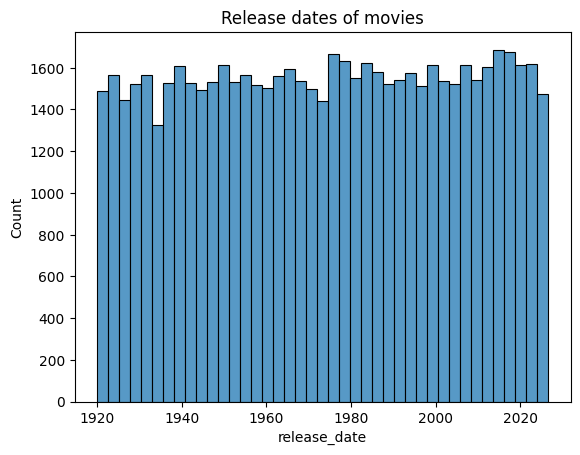

In [179]:
sns.histplot(full_movies['release_date'])
plt.title("Release dates of movies")

Text(0.5, 1.0, 'Ratings Distribution')

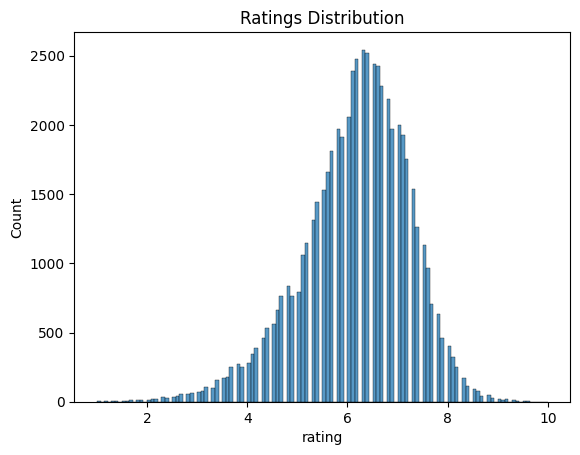

In [180]:
sns.histplot(full_movies['rating'])
plt.title('Ratings Distribution')

## Keyword Filtering

In [181]:
import pandas as pd
import numpy as np

df = pd.read_pickle('data/full_clean.pkl')
df.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,languages,keywords,eng_lang
0,tt0027483,The Crimson Circle,76.0,NaN,6.4,30.0,NaN,NaN,1936-08-10,['Drama'],['English'],NaN,1
1,tt0058131,The Mystery of Thug Island,96.0,NaN,5.0,114.0,NaN,NaN,1966-05-28,['Adventure'],['Italian'],NaN,0
2,tt0042760,Las mujeres de mi general,112.0,Not Rated,6.8,74.0,NaN,NaN,1951-07-13,"['Drama', 'War']",['Spanish'],NaN,0
3,tt0027667,Gentle Julia,62.0,Approved,6.8,38.0,NaN,NaN,1936-04-10,"['Comedy', 'Drama', 'Romance']",['English'],NaN,1
4,tt0055747,Love at Twenty,110.0,NaN,7.2,2500.0,NaN,NaN,1963-02-06,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN,0


In [182]:
print(len(df))

63663


In [183]:
#explode keywords lists and make them lowercase, count the words
keyword_counts = df.explode('keywords')['keywords'].str.lower().value_counts()
#get the popular keywords by filtering on those that happen 100+ times
popular_keywords = set(keyword_counts[keyword_counts >= 100].index)

In [184]:
#filter the popular keywords in the keyword lists
def filter_popular(kw_list):
    #if it's not a list return as is
    if not isinstance(kw_list, list):
        return kw_list
    #keep only keywords that exist in the popular set
    return [kw for kw in kw_list if str(kw).lower() in popular_keywords]

#apply to the column
df['keywords'] = df['keywords'].apply(filter_popular)

In [185]:
df['keywords'].value_counts()

keywords
[]                                                                                                                  11909
[woman director]                                                                                                      764
[independent film]                                                                                                    589
[musical]                                                                                                             344
[sport]                                                                                                               205
                                                                                                                    ...  
[paris, gang]                                                                                                           1
[male nudity, nudity, biography, torture]                                                                               1
[corruption, ba

In [186]:
len(df)

63663

In [187]:
len(popular_keywords)

135

In [188]:
df.to_pickle('data/full_clean.pkl')

## Genre Feature Engineering


Here, We convert the multi-label genres column into machine-learning-ready features.

Rare genres are removed using a frequency threshold, and the remaining genres are one-hot encoded into binary indicator variables (genre_*).

These features will be used by downstream prediction models.

In [189]:
# look at raw genre structure
print(type(df.loc[0, "genres"]))
df["genres"].head(10)

<class 'str'>


0                             ['Drama']
1                         ['Adventure']
2                      ['Drama', 'War']
3        ['Comedy', 'Drama', 'Romance']
4                  ['Drama', 'Romance']
5    ['Dark Comedy', 'Comedy', 'Drama']
6                             ['Drama']
7                 ['Comedy', 'Mystery']
8                ['Biography', 'Drama']
9                      ['Drama', 'War']
Name: genres, dtype: object

In [190]:
# ensure every row is a list of strings
def clean_genres(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [g.strip() for g in x if str(g).strip() != ""]
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            x = x[1:-1]
            return [g.strip().strip("'").strip('"') for g in x.split(",") if g.strip()]
        return [g.strip() for g in x.split(",") if g.strip()]
    return []

df["genres"] = df["genres"].apply(clean_genres)

# check result
df["genres"].head(10)

0                         [Drama]
1                     [Adventure]
2                    [Drama, War]
3        [Comedy, Drama, Romance]
4                [Drama, Romance]
5    [Dark Comedy, Comedy, Drama]
6                         [Drama]
7               [Comedy, Mystery]
8              [Biography, Drama]
9                    [Drama, War]
Name: genres, dtype: object

In [191]:
# count how many movies each genre appears in (frequency of movies per genre)
genre_counts = df["genres"].explode().value_counts()

print("Total unique genres:", len(genre_counts))
genre_counts.head(20)

Total unique genres: 192


genres
Drama          36135
Comedy         19183
Romance        14299
Thriller        9782
Crime           9690
Action          8549
Adventure       6829
Horror          5466
Mystery         5289
Western         3747
Fantasy         3489
War             3232
Sci-Fi          3199
Family          3144
Documentary     3036
Musical         2763
History         2481
Biography       2392
Music           2338
Dark Comedy     1838
Name: count, dtype: int64

In [192]:
# threshold (Here, we put 100 is a reasonable course project choice - could also choose 50 or 200, etc. depending on how many genres you want to keep)
MIN_GENRE_COUNT = 100

kept_genres = set(genre_counts[genre_counts >= MIN_GENRE_COUNT].index)

print("Keeping", len(kept_genres), "genres")

# filter genres per movie (do NOT drop movies)
df["genres_filtered"] = df["genres"].apply(
    lambda gs: [g for g in gs if g in kept_genres]
)

# check how many movies lost all genres
print("Movies with no remaining genres:",
      (df["genres_filtered"].str.len() == 0).mean())

Keeping 104 genres
Movies with no remaining genres: 0.012377676201247191


In [193]:
# convert multi-label list into dummy variables
genre_dummies = df["genres_filtered"].str.join("|").str.get_dummies(sep="|")

# prefix columns so models know these are features
genre_dummies = genre_dummies.add_prefix("genre_")

# attach to dataframe
df = pd.concat([df, genre_dummies], axis=1)

print("Added", genre_dummies.shape[1], "genre features")
df.filter(like="genre_").head()

Added 104 genre features


,genre_Action,genre_Action Epic,genre_Adult Animation,genre_Adventure,genre_Adventure Epic,genre_Alien Invasion,genre_Animal Adventure,genre_Animation,genre_Anime,genre_B-Horror,...,genre_Tragic Romance,genre_True Crime,genre_Urban Adventure,genre_Vampire Horror,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [194]:
# Finalize & Save Feature Dataset

# remove temporary helper column
df.drop(columns=["genres_filtered"], inplace=True)

# overwrite shared dataset for teammates
df.to_pickle("data/full_clean.pkl")

# confirmation logs
print("Updated dataset saved.")
print("Final shape:", df.shape)

genre_cols = [c for c in df.columns if c.startswith("genre_")]
print("Number of genre features:", len(genre_cols))

Updated dataset saved.
Final shape: (63663, 117)
Number of genre features: 104


In [195]:
df.filter(like="genre_").sum().sort_values(ascending=False).head(10)

genre_Drama        36135
genre_Comedy       19183
genre_Romance      14299
genre_Thriller      9782
genre_Crime         9690
genre_Action        8549
genre_Adventure     6829
genre_Horror        5466
genre_Mystery       5289
genre_Western       3747
dtype: int64

# Worldwide Gross

In [196]:
df[df['gross_worldwide'].notna()].head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_Tragic Romance,genre_True Crime,genre_Urban Adventure,genre_Vampire Horror,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror
9,tt0889588,The Children of Huang Shi,125.0,R,7.0,10000.0,"$7,785,975","$1,031,872",2008-06-13,"[Drama, War]",...,0,0,0,0,1,0,0,0,0,0
13,tt9104622,Mirando Al Cielo,122.0,NaN,7.3,53.0,"$626,319","$295,539",2023-05-10,[Drama],...,0,0,0,0,0,0,0,0,0,0
16,tt6859352,Support the Girls,93.0,R,6.4,8600.0,"$139,550","$129,124",2018-08-24,"[Comedy, Drama]",...,0,0,0,0,0,0,0,0,0,0
19,tt0342300,Dopamine,79.0,R,5.9,1200.0,"$69,544","$69,544",2003-01-23,"[Comedy, Drama, Romance]",...,0,0,0,0,0,0,0,0,0,0
20,tt3729920,The Disappearance of Eleanor Rigby: Them,123.0,R,6.3,13000.0,"$1,448,076","$587,774",2014-09-12,"[Drama, Romance]",...,0,0,0,0,0,0,0,0,0,0


In [197]:
currencies = df['gross_worldwide'].str.replace(r'[0-9\.,\s]', '', regex=True)

unique_currencies = currencies.unique()

unique_currencies

array([nan, '$', 'HK$', '₹', '£'], dtype=object)

In [198]:
symbol_to_currency = {
    'HK$': 'HKD',
    '₹': 'INR',
    '£': 'GBP',
    '$': 'USD'
}

In [199]:
currency_conversions = {
    ('HKD', date(1982, 10, 13)): 6.11,
    ('INR', date(1997, 12, 19)): 40,
    ('INR', date(1999, 4, 10)): 42.78,
    ('INR', date(2000, 10, 26)): 46.05,
    ('INR', date(1995, 9, 8)): 32.26,
    ('INR', date(1977, 11, 11)): 8.7,
    ('INR', date(1995, 10, 23)): 35.65,
    ('INR', date(1991, 11, 25)): 25.77,
    ('INR', date(1995, 1, 15)): 31.38,
    ('INR', date(1984, 10, 22)): 12.10,
    ('GBP', date(1947, 12, 22)): 4.03,
    ('GBP', date(1941, 1, 3)): 4.03,
    ('GBP', date(1935, 2, 7)): 4.9
}

In [200]:
c = CurrencyConverter(fallback_on_missing_rate=True)

def extract_currency(gross_string):
    if pd.isna(gross_string):
        return None, None
        
    clean_string = str(gross_string).replace(',', '')
    match = re.match(r'([^\d\s]+)\s*([\d\.]+)', clean_string)
    
    if match:
        symbol = match.group(1).strip()
        amount = float(match.group(2))
        
        # Look up currency, default to USD
        iso_code = symbol_to_currency.get(symbol, 'USD') 
        return iso_code, amount
        
    return 'USD', None

def convert_to_usd(row):
    code = row['currency_code']
    amount = row['nominal_gross']
    release_date = row['release_date']
    
    # Check if the date is missing
    if pd.isna(amount) or pd.isna(release_date):
        return None
    if code == 'USD':
        return amount
    
    # Manually handle historical conversions
    if (code, release_date.date()) in currency_conversions:
        return amount * currency_conversions[(code, release_date.date())]
        
    try:
        return c.convert(amount, code, 'USD', date=release_date.date())
    except Exception as e:
        print(f"Notice: Conversion failed for {code} on {release_date.date()}. Error: {e}")
        return None

def adjust_for_inflation(row):
    amount = row['historical_usd']
    release_date = row['release_date']
        
    if pd.isna(amount) or pd.isna(release_date):
        return None
        
    try:
        return cpi.inflate(amount, release_date.year)
    except Exception:
        return amount

In [202]:
df[['currency_code', 'nominal_gross']] = df['gross_worldwide'].apply(
    lambda x: pd.Series(extract_currency(x))
)
print(1)
df['historical_usd'] = df.apply(convert_to_usd, axis=1)
print(2)
df['inflation_adjusted_usd'] = df.apply(adjust_for_inflation, axis=1)

df.head()

1
2


,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,currency_code,nominal_gross,historical_usd,inflation_adjusted_usd
0,tt0027483,The Crimson Circle,76.0,NaN,6.4,30.0,NaN,NaN,1936-08-10,[Drama],...,0,0,0,0,0,0,None,NaN,NaN,NaN
1,tt0058131,The Mystery of Thug Island,96.0,NaN,5.0,114.0,NaN,NaN,1966-05-28,[Adventure],...,0,0,0,0,0,0,None,NaN,NaN,NaN
2,tt0042760,Las mujeres de mi general,112.0,Not Rated,6.8,74.0,NaN,NaN,1951-07-13,"[Drama, War]",...,1,0,0,0,0,0,None,NaN,NaN,NaN
3,tt0027667,Gentle Julia,62.0,Approved,6.8,38.0,NaN,NaN,1936-04-10,"[Comedy, Drama, Romance]",...,0,0,0,0,0,0,None,NaN,NaN,NaN
4,tt0055747,Love at Twenty,110.0,NaN,7.2,2500.0,NaN,NaN,1963-02-06,"[Drama, Romance]",...,0,0,0,0,0,0,None,NaN,NaN,NaN


In [203]:
df[df.notna().all(axis=1)].head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,currency_code,nominal_gross,historical_usd,inflation_adjusted_usd
9,tt0889588,The Children of Huang Shi,125.0,R,7.0,10000.0,"$7,785,975","$1,031,872",2008-06-13,"[Drama, War]",...,1,0,0,0,0,0,USD,7785975.0,7785975.0,1.164238e+07
19,tt0342300,Dopamine,79.0,R,5.9,1200.0,"$69,544","$69,544",2003-01-23,"[Comedy, Drama, Romance]",...,0,0,0,0,0,0,USD,69544.0,69544.0,1.216805e+05
20,tt3729920,The Disappearance of Eleanor Rigby: Them,123.0,R,6.3,13000.0,"$1,448,076","$587,774",2014-09-12,"[Drama, Romance]",...,0,0,0,0,0,0,USD,1448076.0,1448076.0,1.969274e+06
35,tt0463903,Be with Me,93.0,Not Rated,7.0,1800.0,"$91,297","$1,365",2005-09-08,"[Drama, Romance]",...,0,0,0,0,0,0,USD,91297.0,91297.0,1.504989e+05
39,tt1864405,Low Down,114.0,R,6.1,2300.0,"$54,051","$54,051",2015-01-27,"[Biography, Drama, Music]",...,0,0,0,0,0,0,USD,54051.0,54051.0,7.341811e+04


In [204]:
df[df.notna().all(axis=1)]['inflation_adjusted_usd'].head().to_list()

[11642383.754174348,
 121680.45647826086,
 1969273.5015713708,
 150498.87389144904,
 73418.11386103106]

In [205]:
C = df["rating"].mean()
m = df["votes"].quantile(0.75)

df["normalized_score"] = (
    (df["votes"] / (df["votes"] + m)) * df["rating"]
    + (m / (df["votes"] + m)) * C
)
df.sort_values("normalized_score", ascending=False)[
    ["title","votes","rating","normalized_score"]
].head(20)


,title,votes,rating,normalized_score
31855,The Shawshank Redemption,3000000.0,9.3,9.295406
18654,The Godfather,2100000.0,9.2,9.193650
37638,The Dark Knight,3000000.0,9.0,8.995845
13832,The Lord of the Rings: The Return of the King,2100000.0,9.0,8.994069
40533,Schindler's List,1500000.0,9.0,8.991703
28849,The Godfather Part II,1400000.0,9.0,8.991112
24456,12 Angry Men,918000.0,9.0,8.986468
20971,The Chaos Class,44000.0,9.2,8.923928
34785,Pulp Fiction,2300000.0,8.9,8.894774
60884,The Lord of the Rings: The Fellowship of the Ring,2100000.0,8.9,8.894278


In [206]:
df["votes"].describe()

count    5.959500e+04
mean     1.814791e+04
std      8.445379e+04
min      5.000000e+00
25%      1.650000e+02
50%      7.320000e+02
75%      4.400000e+03
max      3.000000e+06
Name: votes, dtype: float64

In [207]:
df["score_diff"] = df["rating"] - df["normalized_score"]

df.sort_values("score_diff", ascending=False)[
    ["title", "votes", "rating", "normalized_score", "score_diff"]
].head(20)

,title,votes,rating,normalized_score,score_diff
52202,Prisoners of Fire,8.0,10.0,6.170168,3.829832
53849,The College,65.0,9.9,6.217604,3.682396
33204,Day by Day: The Dynasty,11.0,9.7,6.172025,3.527975
63067,Kachchi Jawani,7.0,9.6,6.168664,3.431336
38361,Love Goes Public,15.0,9.6,6.174882,3.425118
47221,Water Brother,31.0,9.6,6.187249,3.412751
48599,SEVENTEEN TOUR 'FOLLOW' to JAPAN: LIVE VIEWING,38.0,9.5,6.191776,3.308224
42233,Twiceland,77.0,9.5,6.220595,3.279405
31060,Steeper & Deeper,22.0,9.4,6.179308,3.220692
38963,Come See Me in the Good Light,26.0,9.4,6.182219,3.217781


In [208]:
df.to_pickle('data/clean_adjusted.pkl')

In [209]:
test = pd.read_pickle('data/clean_adjusted.pkl')

test[test.notna().all(axis=1)].head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,currency_code,nominal_gross,historical_usd,inflation_adjusted_usd,normalized_score,score_diff
9,tt0889588,The Children of Huang Shi,125.0,R,7.0,10000.0,"$7,785,975","$1,031,872",2008-06-13,"[Drama, War]",...,0,0,0,0,USD,7785975.0,7785975.0,1.164238e+07,6.744313,0.255687
19,tt0342300,Dopamine,79.0,R,5.9,1200.0,"$69,544","$69,544",2003-01-23,"[Comedy, Drama, Romance]",...,0,0,0,0,USD,69544.0,69544.0,1.216805e+05,6.106804,-0.206804
20,tt3729920,The Disappearance of Eleanor Rigby: Them,123.0,R,6.3,13000.0,"$1,448,076","$587,774",2014-09-12,"[Drama, Romance]",...,0,0,0,0,USD,1448076.0,1448076.0,1.969274e+06,6.265408,0.034592
35,tt0463903,Be with Me,93.0,Not Rated,7.0,1800.0,"$91,297","$1,365",2005-09-08,"[Drama, Romance]",...,0,0,0,0,USD,91297.0,91297.0,1.504989e+05,6.406145,0.593855
39,tt1864405,Low Down,114.0,R,6.1,2300.0,"$54,051","$54,051",2015-01-27,"[Biography, Drama, Music]",...,0,0,0,0,USD,54051.0,54051.0,7.341811e+04,6.141508,-0.041508


## Recommender

In [1]:
import pandas as pd
df_new = pd.read_csv("data/clean_adjusted.csv")
df_new.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,currency_code,nominal_gross,historical_usd,inflation_adjusted_usd,normalized_score,score_diff
0,tt0027483,The Crimson Circle,76.0,NaN,6.4,30.0,NaN,NaN,1936-08-10,['Drama'],...,0,0,0,0,NaN,NaN,NaN,NaN,6.164809,0.235191
1,tt0058131,The Mystery of Thug Island,96.0,NaN,5.0,114.0,NaN,NaN,1966-05-28,['Adventure'],...,0,0,0,0,NaN,NaN,NaN,NaN,6.133829,-1.133829
2,tt0042760,Las mujeres de mi general,112.0,Not Rated,6.8,74.0,NaN,NaN,1951-07-13,"['Drama', 'War']",...,0,0,0,0,NaN,NaN,NaN,NaN,6.173738,0.626262
3,tt0027667,Gentle Julia,62.0,Approved,6.8,38.0,NaN,NaN,1936-04-10,"['Comedy', 'Drama', 'Romance']",...,0,0,0,0,NaN,NaN,NaN,NaN,6.168657,0.631343
4,tt0055747,Love at Twenty,110.0,NaN,7.2,2500.0,NaN,NaN,1963-02-06,"['Drama', 'Romance']",...,0,0,0,0,NaN,NaN,NaN,NaN,6.538855,0.661145


In [2]:
columns = list(df_new.columns)
df_new.describe()

,duration,rating,votes,eng_lang,genre_Action,genre_Action Epic,genre_Adult Animation,genre_Adventure,genre_Adventure Epic,genre_Alien Invasion,...,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,nominal_gross,historical_usd,inflation_adjusted_usd,normalized_score,score_diff
count,61500.000000,59595.000000,5.959500e+04,63663.000000,63663.000000,63663.000000,63663.000000,63663.000000,63663.000000,63663.000000,...,63663.000000,63663.000000,63663.000000,63663.000000,63663.000000,2.090900e+04,2.090900e+04,2.090900e+04,59595.000000,59595.000000
mean,95.850065,6.163205,1.814791e+04,0.675997,0.134285,0.002717,0.003314,0.107268,0.002466,0.002623,...,0.001854,0.058857,0.004508,0.002168,0.001948,3.547996e+07,3.881374e+07,6.916498e+07,6.246186,-0.082981
std,36.262583,1.070316,8.445379e+04,0.468005,0.340961,0.052059,0.057475,0.309456,0.049599,0.051150,...,0.043013,0.235358,0.066991,0.046508,0.044091,1.171552e+08,2.334812e+08,4.692265e+08,0.457400,0.826926
min,1.000000,1.000000,5.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.728377,-5.144498
25%,82.000000,5.500000,1.650000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.583600e+04,9.600800e+04,1.692588e+05,6.120298,-0.444903
50%,93.000000,6.300000,7.320000e+02,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.656829e+06,1.657729e+06,2.895045e+06,6.166991,0.028910
75%,105.000000,6.900000,4.400000e+03,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.800000e+07,1.800962e+07,3.461008e+07,6.299678,0.381746
max,5220.000000,10.000000,3.000000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.923711e+09,1.882320e+10,3.637453e+10,9.295406,3.829832


In [2]:
scale_cols = ['duration','gross_worldwide','gross_us_canada','nominal_gross','historical_usd','inflation_adjusted_usd'] #columns to scale
reformat = ['gross_worldwide', 'gross_us_canada', 'nominal_gross', 'historical_usd', 'inflation_adjusted_usd']

for col in reformat:
    #only run string cleaning if the data isn't already numeric
    if df_new[col].dtype == 'object':
        #replace $ and commas
        df_new[col] = (df_new[col]
                       .str.replace('$', '', regex=False)
                       .str.replace(',', '', regex=False))
    
    #convert to numeric
    df_new[col] = pd.to_numeric(df_new[col], errors='coerce')
df_new['gross_us_canada'].tail()

63658          NaN
63659    2268181.0
63660          NaN
63661          NaN
63662          NaN
Name: gross_us_canada, dtype: float64

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_new[scale_cols] = scaler.fit_transform(df_new[scale_cols]) #scale the data

In [6]:
columns

['id',
 'title',
 'duration',
 'mpa',
 'rating',
 'votes',
 'gross_worldwide',
 'gross_us_canada',
 'release_date',
 'genres',
 'languages',
 'keywords',
 'eng_lang',
 'genre_Action',
 'genre_Action Epic',
 'genre_Adult Animation',
 'genre_Adventure',
 'genre_Adventure Epic',
 'genre_Alien Invasion',
 'genre_Animal Adventure',
 'genre_Animation',
 'genre_Anime',
 'genre_B-Horror',
 'genre_Biography',
 'genre_Body Horror',
 'genre_Buddy Comedy',
 'genre_Caper',
 'genre_Classical Western',
 'genre_Comedy',
 'genre_Coming-of-Age',
 'genre_Computer Animation',
 'genre_Conspiracy Thriller',
 'genre_Costume Drama',
 'genre_Crime',
 'genre_Dark Comedy',
 'genre_Dark Fantasy',
 'genre_Dark Romance',
 'genre_Docudrama',
 'genre_Documentary',
 'genre_Drama',
 'genre_Dystopian Sci-Fi',
 'genre_Epic',
 'genre_Erotic Thriller',
 'genre_Fairy Tale',
 'genre_Family',
 'genre_Fantasy',
 'genre_Farce',
 'genre_Feel-Good Romance',
 'genre_Film Noir',
 'genre_Folk Horror',
 'genre_Gangster',
 'genre_Hand

In [5]:
genre_cols = [col for col in df_new.columns if col.startswith('genre_')]
feature_cols = ['duration','rating','votes','eng_lang','keywords','gross_worldwide','normalized_score','score_diff'] + genre_cols
feature_cols

['duration',
 'rating',
 'votes',
 'eng_lang',
 'keywords',
 'gross_worldwide',
 'normalized_score',
 'score_diff',
 'genre_Action',
 'genre_Action Epic',
 'genre_Adult Animation',
 'genre_Adventure',
 'genre_Adventure Epic',
 'genre_Alien Invasion',
 'genre_Animal Adventure',
 'genre_Animation',
 'genre_Anime',
 'genre_B-Horror',
 'genre_Biography',
 'genre_Body Horror',
 'genre_Buddy Comedy',
 'genre_Caper',
 'genre_Classical Western',
 'genre_Comedy',
 'genre_Coming-of-Age',
 'genre_Computer Animation',
 'genre_Conspiracy Thriller',
 'genre_Costume Drama',
 'genre_Crime',
 'genre_Dark Comedy',
 'genre_Dark Fantasy',
 'genre_Dark Romance',
 'genre_Docudrama',
 'genre_Documentary',
 'genre_Drama',
 'genre_Dystopian Sci-Fi',
 'genre_Epic',
 'genre_Erotic Thriller',
 'genre_Fairy Tale',
 'genre_Family',
 'genre_Fantasy',
 'genre_Farce',
 'genre_Feel-Good Romance',
 'genre_Film Noir',
 'genre_Folk Horror',
 'genre_Gangster',
 'genre_Hand-Drawn Animation',
 'genre_Heist',
 'genre_High-Con

In [6]:
#clean the keywords
import ast

def clean_keywords(x):
    if isinstance(x, str):
        #convert "[ 'a', 'b' ]" string into an actual python list ['a', 'b']
        try:
            items = ast.literal_eval(x)
            #remove spaces within keywords and lowercase everything
            return " ".join([i.replace(" ", "").lower() for i in items])
        except:
            return ""
    return ""

#apply the cleaning
df_new['keywords_refined'] = df_new['keywords'].apply(clean_keywords)
df_new['keywords_refined'][21]

'martialarts independentfilm violence'

In [7]:
#get genre names
def get_genres(row):
    return " ".join([col.replace('genre_', '') for col in genre_cols if row[col] == 1])

df_new['genre_soup'] = df_new.apply(get_genres, axis=1)

#combine everything into the final soup
df_new['total_metadata_soup'] = df_new['genre_soup'] + " " + df_new['keywords_refined']

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#initialize TF-IDF
tfidf = TfidfVectorizer(stop_words='english')

In [9]:
#construct the TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(df_new['total_metadata_soup'])

In [10]:
#compute cosine similarity
#matrix comparing all the soups to each other
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [11]:
#create the final searchable df
movie_sim_df = pd.DataFrame(cosine_sim, index=df_new['title'], columns=df_new['title'])

In [11]:
movie_sim_df.head()

title,The Crimson Circle,The Mystery of Thug Island,Las mujeres de mi general,Gentle Julia,Love at Twenty,Bye Bye Braverman,The cheat,Strangers of the Night,Rembrandt,The Children of Huang Shi,...,Kiss,The Photograph,Le joker,Married Too Young,The Burning Cross,Girl with an Itch,Texasville,Kalai Arasi,Aprili,Cebo para una adolescente
title,,,,,,,,,,,,,,,,,,,,,
The Crimson Circle,1.000000,0.0,0.367078,0.427694,0.531772,0.245155,1.000000,0.000000,0.343660,0.151702,...,0.360454,0.531772,0.0,0.427694,0.476503,1.000000,0.531772,0.000000,0.427694,0.427694
The Mystery of Thug Island,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Las mujeres de mi general,0.367078,0.0,1.000000,0.156997,0.195202,0.089991,0.367078,0.000000,0.126150,0.413268,...,0.132315,0.195202,0.0,0.156997,0.174913,0.367078,0.195202,0.000000,0.156997,0.156997
Gentle Julia,0.427694,0.0,0.156997,1.000000,0.804281,0.509682,0.427694,0.314024,0.146981,0.064882,...,0.154164,0.804281,0.0,1.000000,0.203797,0.427694,0.804281,0.289221,1.000000,1.000000
Love at Twenty,0.531772,0.0,0.195202,0.804281,1.000000,0.130366,0.531772,0.000000,0.182749,0.080671,...,0.191679,1.000000,0.0,0.804281,0.253391,0.531772,1.000000,0.000000,0.804281,0.804281


In [12]:
def get_similar_movies(movie_title, sim_df, n=5):
    #find the row for the movie and sort by similarity score
    similar_scores = sim_df[movie_title].sort_values(ascending=False)
    
    #return the top N (skip the first one because it's the movie itself)
    return similar_scores.iloc[1:n+1]

In [13]:
get_similar_movies("Iron Man 2",movie_sim_df)

title
Iron Man                              0.948660
X-Men: Apocalypse                     0.871334
Batman v Superman: Dawn of Justice    0.858513
X-Men: The Last Stand                 0.845167
X-Men: First Class                    0.829733
Name: Iron Man 2, dtype: float64

In [20]:
def get_recommendations(movie_title, sim_df, data, n=10):
    #get the similarity scores for the movie
    sim_scores = sim_df[movie_title].sort_values(ascending=False)
    
    #get the top 50 most similar movies
    top_50_idx = sim_scores.iloc[1:51].index
    top_50_movies = data[data['title'].isin(top_50_idx)].copy()
    
    #add the similarity score to this subset
    top_50_movies['sim_score'] = sim_scores.loc[top_50_idx].values
    
    #rank by similarity + a "popularity boost"
    top_50_movies = top_50_movies.sort_values(by=['sim_score', 'votes'], ascending=False)
    
    return top_50_movies[['title', 'sim_score', 'votes', 'rating']].head(n)

In [21]:
get_recommendations("Toy Story", movie_sim_df, df_new, n=5)

,title,sim_score,votes,rating
452,Wish Dragon,0.776682,36000.0,7.2
2484,Missing Link,0.751317,455.0,6.0
1582,Luck,0.751317,19.0,7.4
2947,"Monsters, Inc.",0.746761,1000000.0,8.1
3081,Delgo,0.738344,3300.0,4.3


In [22]:
get_recommendations("Texasville", movie_sim_df, df_new, n=5)

,title,sim_score,votes,rating
1794,Blue Jay,1.0,21000.0,7.2
41053,Love Letter,1.0,12000.0,7.9
36230,Time to Love,1.0,8100.0,7.9
49655,Hungry Hearts,1.0,6100.0,6.5
36667,Old Acquaintance,1.0,4000.0,7.4


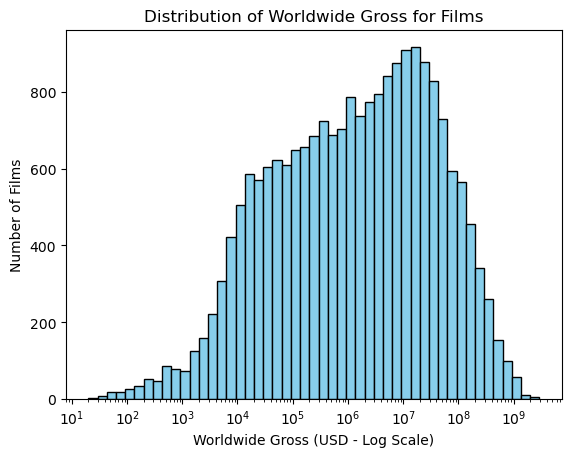

In [16]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.logspace(np.log10(20), np.log10(df_new['gross_worldwide'].max()), 50)

plt.hist(df_new['gross_worldwide'],bins=bins,color='skyblue',edgecolor='black')
plt.title('Distribution of Worldwide Gross for Films')
plt.gca().set_xscale('log')
plt.xlabel('Worldwide Gross (USD - Log Scale)')
plt.ylabel('Number of Films')
plt.show()

In [26]:
num_english = df_new['eng_lang'].sum()
num_non_english = len(df_new) - num_english
num_non_english

np.int64(20627)

Text(0.5, 1.0, 'Distribution of English vs. Non-English Language Films')

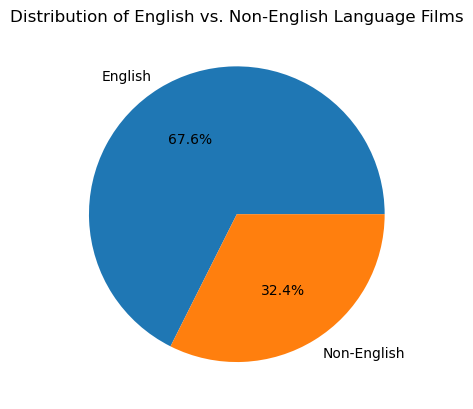

In [30]:
labels = 'English', 'Non-English'
sizes = [num_english, num_non_english]

plt.pie(sizes, labels=labels,autopct='%1.1f%%')
plt.title('Distribution of English vs. Non-English Language Films')

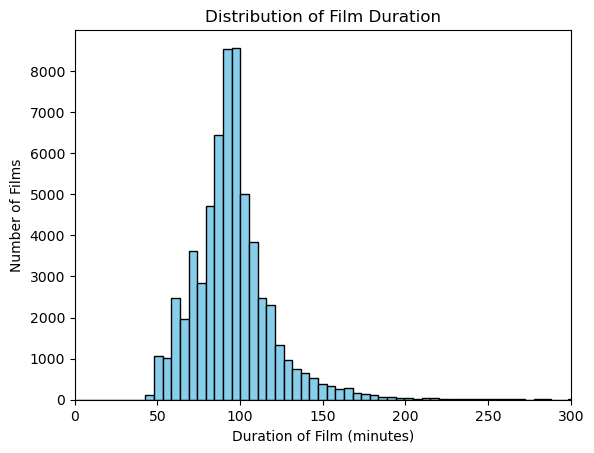

In [ ]:

plt.hist(df_new['duration'],bins=1000,color='skyblue',edgecolor='black')
plt.title('Distribution of Film Duration')
plt.xlim(0,300)
plt.xlabel('Duration of Film (minutes)')
plt.ylabel('Number of Films')
plt.show()